# Classification Models in scikit-learn

In [1]:
import pandas as pd
# load the iris dataset

path = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Practice/master/Data/iris.csv'
iris = pd.read_csv(path)

In [2]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
# number of flowers
len(iris)

150

In [4]:
iris.species.value_counts()

Iris-virginica     50
Iris-versicolor    50
Iris-setosa        50
Name: species, dtype: int64

## classification example: the k-nearest neighbors and logistic regression

In [5]:
# step 1: arrange data into the 'feature matrix' and the 'target vector'

X = iris.drop('species', axis=1)

In [6]:
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [7]:
y = iris.species

In [8]:
y

0         Iris-setosa
1         Iris-setosa
2         Iris-setosa
3         Iris-setosa
4         Iris-setosa
            ...      
145    Iris-virginica
146    Iris-virginica
147    Iris-virginica
148    Iris-virginica
149    Iris-virginica
Name: species, Length: 150, dtype: object

***Step 2***

In [9]:
# import the classification model from scikit learn

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

***Step 3***

In [10]:
# instantiate the models

knn_clf = KNeighborsClassifier(n_neighbors = 20)
log_clf = LogisticRegression()

***Step 4***

In [11]:
# fit the model to the data // 'model training'

knn_clf.fit(X,y)

log_clf.fit(X,y)

LogisticRegression()

***Step 5***

In [12]:
# apply models to the data

new_flowers = [[3,5,4,2],[5,4,3,1]] # two new flowers

new_flowers

[[3, 5, 4, 2], [5, 4, 3, 1]]

In [13]:
knn_clf.predict(new_flowers)

array(['Iris-versicolor', 'Iris-setosa'], dtype=object)

In [14]:
log_clf.predict(new_flowers)

array(['Iris-setosa', 'Iris-setosa'], dtype=object)

Questions:
- How do knn and logistic regression work?
- How do I choose hyperparameters?
- Will my classifier perform well on new data?
- Which classifier should I use?

### k-nearest neighbors classifier examples

Example 1: The three blobs dataset

In [15]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

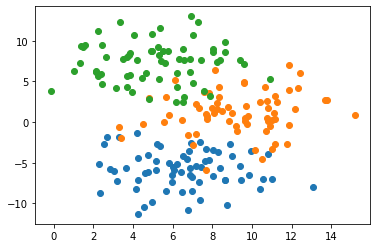

In [16]:
X,y = make_blobs(n_samples=200,centers = 3,cluster_std=2.5)

plt.scatter(X[y==0,0],X[y==0,1])
plt.scatter(X[y==1,0],X[y==1,1])
plt.scatter(X[y==2,0],X[y==2,1])

In [17]:
# plot classification regrions function
# -*- coding: utf-8 -*-
"""
Created on Thu Sep 16 14:29:00 2021
Updated on Tue Oct 19 09:00:00 2021

@author: javier.perez-alvaro
"""
import matplotlib.pyplot as plt
import numpy as np
def draw_classification_regions(X,y,model):
    
    # classes 
    classes = model.classes_
    # feature names
    try:
        feature_names = X.columns
    except:
        feature_names = ['feature #1','feature #2']
    
    # put data into numpy arrays
    try:
        X = np.array(X)
        y = np.array(y).flatten()
    except:
        print('something went wrong')
    
    from matplotlib.colors import ListedColormap
    # create a mesh grid
    h = .1
    x_min, x_max = X[:, 0].min() - .1, X[:, 0].max() + .1
    y_min, y_max = X[:, 1].min() - .1, X[:, 1].max() + .1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # evaluate classifier at all mesh grid points
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # number of classes
    n_classes = len(np.unique(y))
    
    # map classes to 0,1,2
    for i in range(n_classes):
        Z[Z==classes[i]]=i

    # Put the result into a color plot
    fig, ax = plt.subplots(figsize=(10,5))
    colors = ['C0','C1','C2']
    if n_classes==3:
        custom_cmap = ListedColormap(['#9898ff','#fafab0','#a0faa0'])
    else:
        custom_cmap = ListedColormap(['#9898ff','#fafab0'])
        
    ax.contourf(xx, yy, Z, cmap=custom_cmap)

    # plot dataset
    for i in range(n_classes):
        ax.scatter(X[y==classes[i],0], X[y==classes[i],1], c = colors[i], label=classes[i], s=75, alpha=0.8)

    ax.set_xlabel(feature_names[0], fontsize=15)
    ax.set_ylabel(feature_names[1], fontsize=15)

    ax.legend()

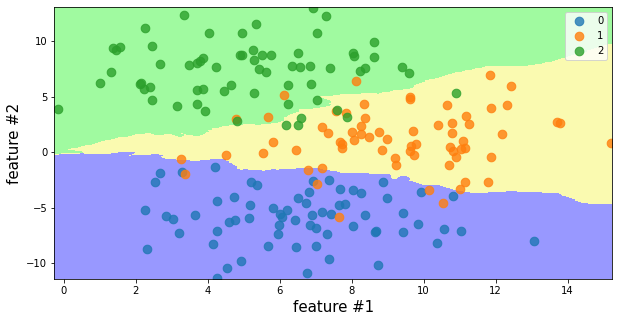

In [18]:
knn_clf = KNeighborsClassifier(n_neighbors = 16)
knn_clf.fit(X,y)

draw_classification_regions(X,y,knn_clf)

## Logistic Regression

A binary classification algorithm

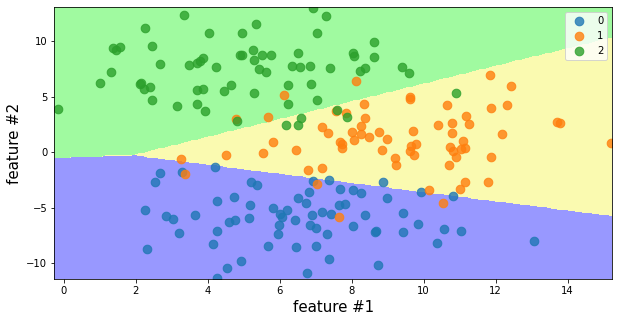

In [19]:
log_reg = LogisticRegression()
log_reg.fit(X,y)
draw_classification_regions(X,y,log_reg)

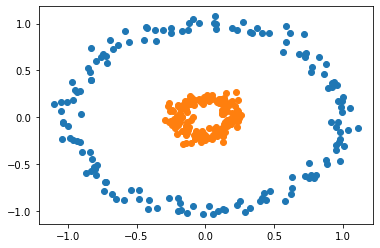

In [22]:
# two-circles dataset
from sklearn.datasets import make_circles
X,y = make_circles(n_samples=300, noise=0.05, factor =0.2)

plt.scatter(X[y==0, 0], X[y==0,1])
plt.scatter(X[y==1, 0], X[y==1,1])

In [23]:
knn_clf.fit(X,y)

KNeighborsClassifier(n_neighbors=16)

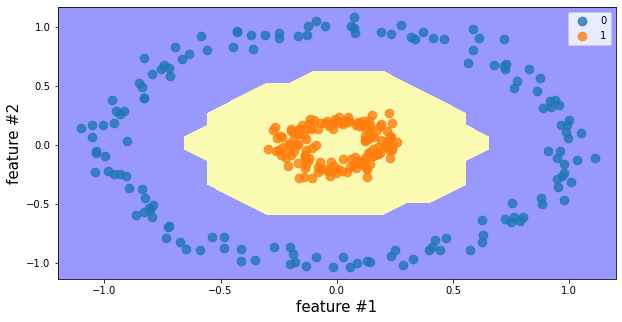

In [24]:
draw_classification_regions(X,y,knn_clf)

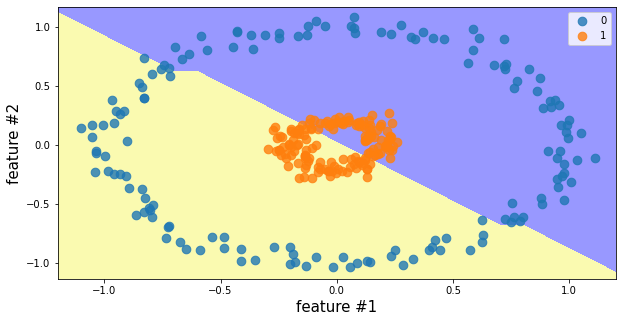

In [25]:
log_reg.fit(X,y)
draw_classification_regions(X,y,log_reg)